Project: Bank Customer Churn Predictor

Domain: Retail Banking

Dataset: ABC Multistate Bank Customer Dataset (10k Records)

Business Objective
To build a machine learning pipeline that predicts which banking customers are likely to close their accounts. The system is designed to help the retention team understand the main reasons for customer churn so they can intervene early.

Architectural Pipeline (Medallion Architecture)

Bronze Layer (Raw Data): Ingestion of the raw banking dataset containing customer demographics, account balances, and product usage.

Silver Layer (Clean & Enhance): Removal of non-predictive identifiers (RowNumber, CustomerId, Surname). Application of One-Hot Encoding for categorical geography. Creation of engineered financial metrics like the Balance-to-Salary Ratio.

Gold Layer (Model Ready): Splitting the data into training and testing sets. Applying SMOTE strictly on the training data to balance the churn vs. non-churn classes without causing data leakage.

Modeling (Future State): Building a multi-model pipeline (Logistic Regression, Decision Tree, Random Forest, XGBoost) to predict churn, using MLflow to track performance.

Author: Pruthvi Chavda
Date: August 2026

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
raw=pd.read_csv('../data/raw/Bank Customer Churn Prediction.csv')
print(raw.shape)
df=raw.copy()
raw.head()

(10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.drop('customer_id',axis=1,inplace=True)

In [6]:
df.isna().sum()

credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [7]:
df.columns

Index(['credit_score', 'country', 'gender', 'age', 'tenure', 'balance',
       'products_number', 'credit_card', 'active_member', 'estimated_salary',
       'churn'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   credit_score      10000 non-null  int64  
 1   country           10000 non-null  str    
 2   gender            10000 non-null  str    
 3   age               10000 non-null  int64  
 4   tenure            10000 non-null  int64  
 5   balance           10000 non-null  float64
 6   products_number   10000 non-null  int64  
 7   credit_card       10000 non-null  int64  
 8   active_member     10000 non-null  int64  
 9   estimated_salary  10000 non-null  float64
 10  churn             10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 859.5 KB


In [10]:
df.describe()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [11]:
df.isna().sum()

credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [12]:
for i in df.select_dtypes(include="object").columns:
    df[i] = df[i].str.strip().str.lower()

C:\Users\admin\AppData\Local\Temp\ipykernel_10732\3475928079.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for i in df.select_dtypes(include="object").columns:


In [13]:
X=df.drop('churn',axis=1)
y=df['churn']
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
df['churn'].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

In [15]:
df_train=pd.concat([x_train,y_train],axis=1)

In [16]:
df_train

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
9254,686,france,male,32,6,0.00,2,1,1,179093.26,0
1561,632,germany,male,42,4,119624.60,2,1,1,195978.86,0
1670,559,spain,male,24,3,114739.92,1,1,0,85891.02,1
6087,561,france,female,27,9,135637.00,1,1,0,153080.40,1
6669,517,france,male,56,9,142147.32,1,0,0,39488.04,1
...,...,...,...,...,...,...,...,...,...,...,...
5734,768,france,male,54,8,69712.74,1,1,1,69381.05,0
5191,682,france,female,58,1,0.00,1,1,1,706.50,0
5390,735,france,female,38,1,0.00,3,0,0,92220.12,1
860,667,france,male,43,8,190227.46,1,1,0,97508.04,1


In [17]:
df_train['churn'].value_counts()

churn
0    6356
1    1644
Name: count, dtype: int64

<Axes: >

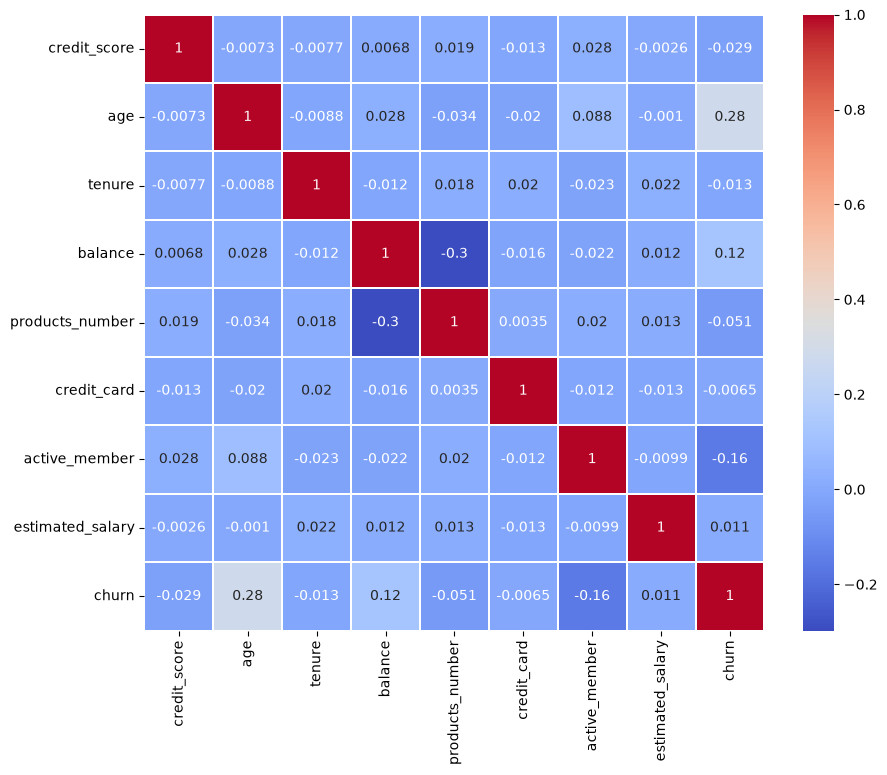

In [18]:
num_df=df_train.select_dtypes(include=['int64','float64'])
corr=num_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr,annot=True,cmap='coolwarm',linewidths=0.1)
#

<Axes: xlabel='churn', ylabel='balance'>

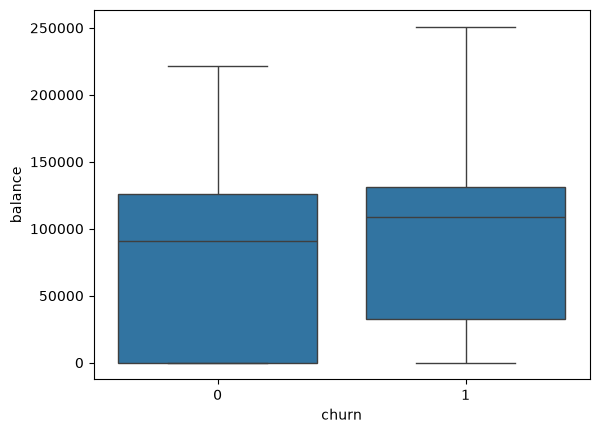

In [19]:
sns.boxplot(x='churn',y='balance',data=df_train)

<Axes: xlabel='churn', ylabel='age'>

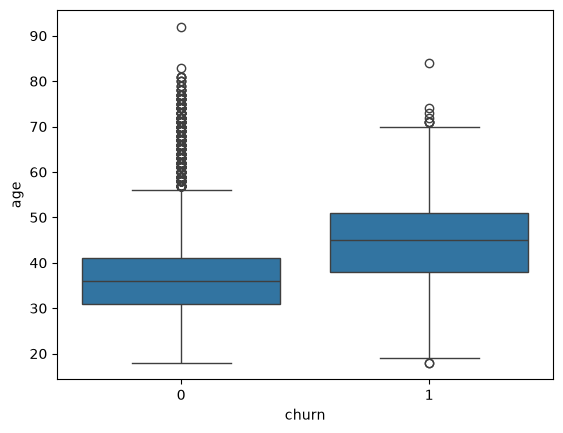

In [20]:
sns.boxplot(x='churn',y='age',data=df_train)

<Axes: xlabel='churn', ylabel='count'>

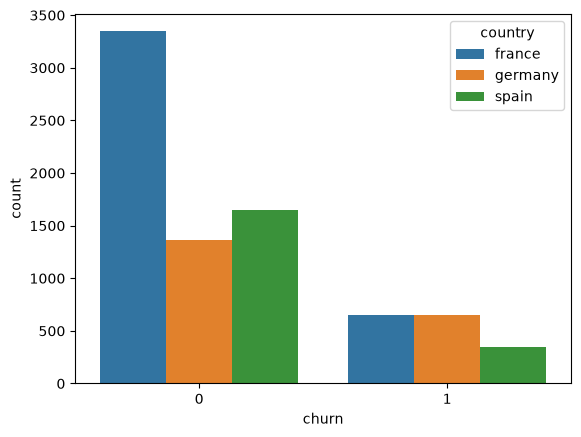

In [21]:
sns.countplot(x='churn',hue='country',data=df_train)

In [22]:
df_train.groupby('active_member')['churn'].value_counts()

active_member  churn
0              0        2844
               1        1054
1              0        3512
               1         590
Name: count, dtype: int64

In [23]:
df_train.groupby('active_member')['churn'].value_counts(normalize=True) * 100

active_member  churn
0              0        72.960493
               1        27.039507
1              0        85.616772
               1        14.383228
Name: proportion, dtype: float64

In [24]:
1054/590

1.7864406779661017

In [26]:
from src.components.transformers import RatioFeatureEngineering

x_train_temp = x_train.copy()

trans=RatioFeatureEngineering()

xtrans=trans.fit_transform(x_train_temp)

In [29]:
xtrans

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,Balance_to_Salary,Tenure_to_Age,Active_Product_Multiplier,Credit_Score_per_Age
9254,686,france,male,32,6,0.00,2,1,1,179093.26,0.000000,0.187500,2,21.437500
1561,632,germany,male,42,4,119624.60,2,1,1,195978.86,0.610395,0.095238,2,15.047619
1670,559,spain,male,24,3,114739.92,1,1,0,85891.02,1.335878,0.125000,0,23.291667
6087,561,france,female,27,9,135637.00,1,1,0,153080.40,0.886051,0.333333,0,20.777778
6669,517,france,male,56,9,142147.32,1,0,0,39488.04,3.599756,0.160714,0,9.232143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,768,france,male,54,8,69712.74,1,1,1,69381.05,1.004781,0.148148,1,14.222222
5191,682,france,female,58,1,0.00,1,1,1,706.50,0.000000,0.017241,1,11.758621
5390,735,france,female,38,1,0.00,3,0,0,92220.12,0.000000,0.026316,0,19.342105
860,667,france,male,43,8,190227.46,1,1,0,97508.04,1.950890,0.186047,0,15.511628
